In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC # C de clasificación
from sklearn.svm import SVR # R de regresión
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay,mean_squared_error, r2_score

In [94]:
from sklearn.datasets import load_wine
from sklearn import datasets
wine = datasets.load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

print("Características:", feature_names)
print("Clases:", class_names)

Características: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Clases: ['class_0' 'class_1' 'class_2']


In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [96]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Núcleo lineal

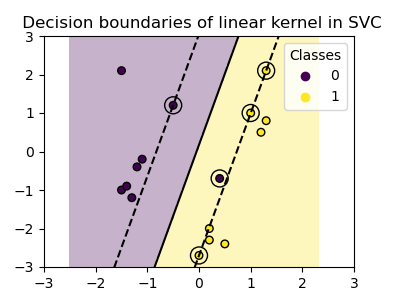

# Núcleo polinomial

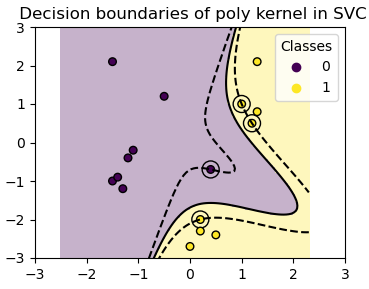

# Núcleo RBF

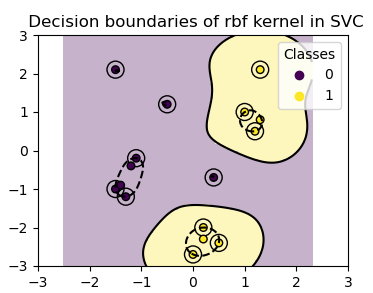

# Núcleo sigmoideo

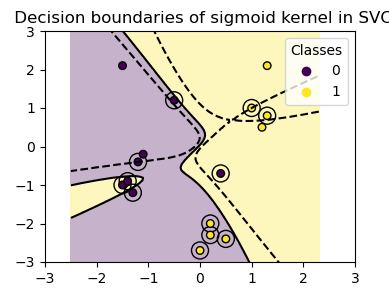

# Selección de Kernel

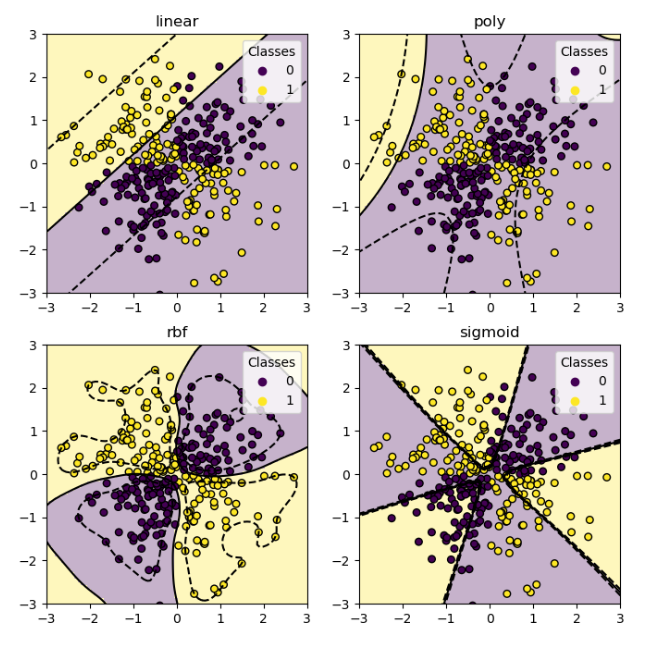

In [97]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)

SVC(random_state=42)

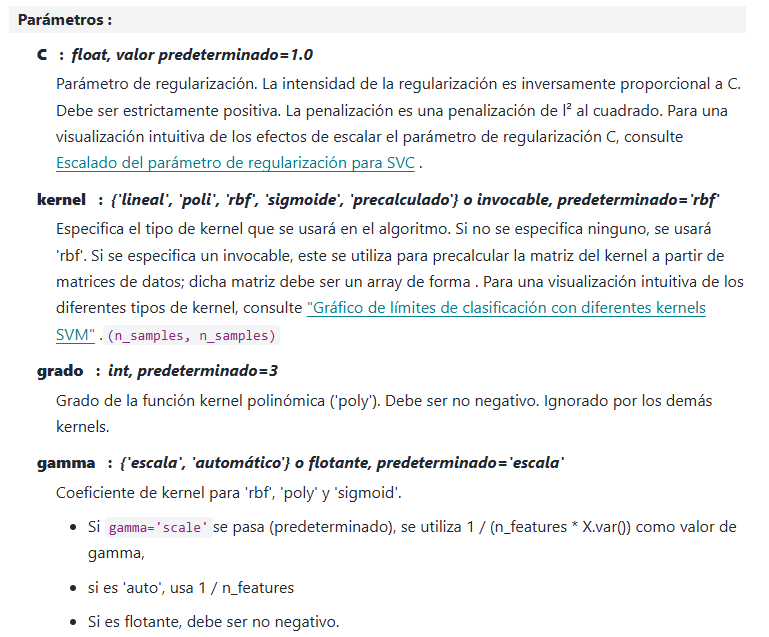

In [98]:
y_pred = svm.predict(X_test_scaled)

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred, target_names=class_names))


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



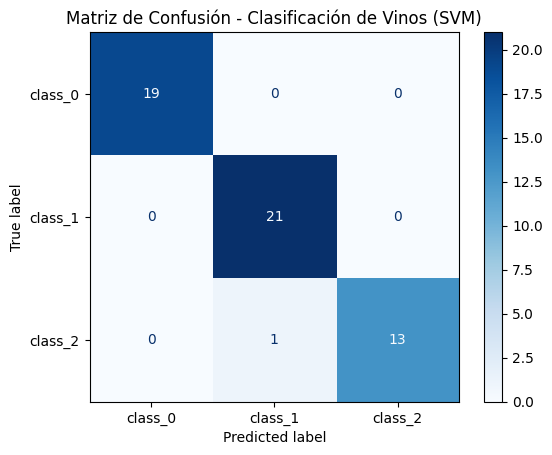

In [99]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Clasificación de Vinos (SVM)")
plt.show()

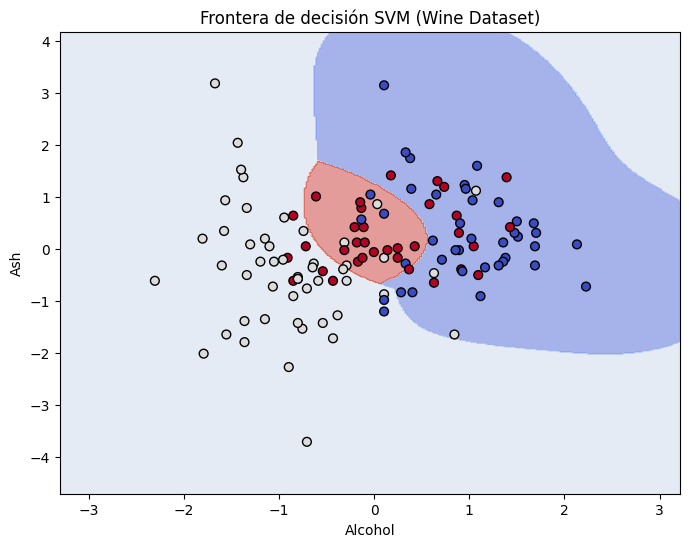

In [100]:
X_vis = X_train_scaled[:, [0, 2]]  # alcohol y ash (cenizas)
y_vis = y_train

svm_vis = SVC(kernel='rbf', gamma=0.5)
svm_vis.fit(X_vis, y_vis)

# Crear una malla para graficar la frontera
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.5)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=plt.cm.coolwarm, edgecolors='k', s=40)
plt.xlabel(feature_names[0].capitalize())
plt.ylabel(feature_names[2].capitalize())
plt.title("Frontera de decisión SVM (Wine Dataset)")
plt.show()

**Regresión**

In [101]:
svm1 = SVR(kernel='linear', gamma='scale')
svm1.fit(X_train_scaled, y_train)

SVR(kernel='linear')

In [102]:
y_pred1 = svm1.predict(X_test_scaled)

In [103]:
mse = mean_squared_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred)
print("Error cuadrático medio (MSE):", round(mse, 3))
print("Coeficiente de determinación (R²):", round(r2, 3))

Error cuadrático medio (MSE): 0.058
Coeficiente de determinación (R²): 0.969


In [104]:
y_pred_classes = svm.predict(X_test_scaled)
print("Primeras 10 predicciones de clase:")
print(y_pred_classes[:10])

Primeras 10 predicciones de clase:
[0 0 2 0 1 0 1 2 1 2]


# **Redes Nuronales**

In [105]:
import numpy as np
import tensorflow as tf            # libreria para deep learning
import matplotlib.pyplot as plt

In [106]:
celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)    # conjunto de entrenamiento  variable X
fahrentheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float) #conjunto objetivo varieble Y

In [107]:
capa = tf.keras.layers.Dense(units=1,  input_shape=[1])   # Todas conectadas
modelo = tf.keras.Sequential([capa])                      # una red detras de la otra secuencial

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [108]:
from sklearn import metrics
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),  # opomizador ADAM Mometum
    loss='mean_squared_error',
    metrics=['accuracy']
)

In [109]:
historial = modelo.fit(celsius, fahrentheit, epochs=500, verbose=False) # formato X, Y, Epocas de entrenemiento

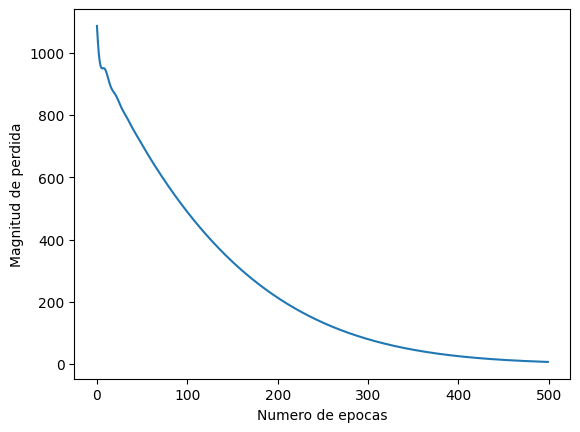

In [110]:
plt.xlabel("Numero de epocas")
plt.ylabel("Magnitud de perdida")
plt.plot(historial.history["loss"])
plt.show()

In [111]:
prediccion = modelo.predict(np.array([100], dtype=float))
print("El resultado es " + str(prediccion) + " fahrenheit")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
El resultado es [[211.33812]] fahrenheit


In [112]:
print("Variables internas del modelo")
print(capa.get_weights())

Variables internas del modelo
[array([[1.8201454]], dtype=float32), array([29.32358], dtype=float32)]


# Más capas mayor precición menor explicabilidad

In [113]:
capa_oculta = tf.keras.layers.Dense(units=3, input_shape=[1])
capa_oculta2 = tf.keras.layers.Dense(units=3)
capa_salida = tf.keras.layers.Dense(units=1)
modelo2 = tf.keras.Sequential([capa_oculta, capa_oculta2,capa_salida])

In [114]:
modelo2.variables

[<Variable path=sequential_3/dense_3/kernel, shape=(1, 3), dtype=float32, value=[[-0.5032516   0.30812275  0.78943026]]>,
 <Variable path=sequential_3/dense_3/bias, shape=(3,), dtype=float32, value=[0. 0. 0.]>,
 <Variable path=sequential_3/dense_4/kernel, shape=(3, 3), dtype=float32, value=[[-0.87463975 -0.976938   -0.7574079 ]
  [-0.7082982   0.271096    0.9790766 ]
  [-0.28018594  0.9510834  -0.75111794]]>,
 <Variable path=sequential_3/dense_4/bias, shape=(3,), dtype=float32, value=[0. 0. 0.]>,
 <Variable path=sequential_3/dense_5/kernel, shape=(3, 1), dtype=float32, value=[[-1.0163361e+00]
  [-4.0996075e-04]
  [-6.0969043e-01]]>,
 <Variable path=sequential_3/dense_5/bias, shape=(1,), dtype=float32, value=[0.]>]

In [116]:
modelo2.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error',
    metrics=[tf.keras.metrics.MeanAbsoluteError()])

In [117]:
historial2 = modelo2.fit(celsius, fahrentheit, epochs=100, verbose=False)

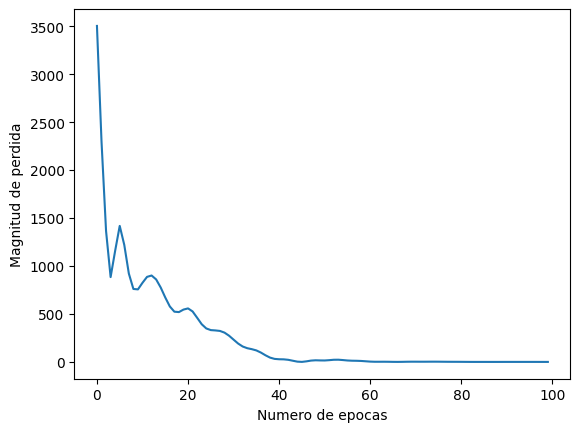

In [118]:
plt.xlabel("Numero de epocas")
plt.ylabel("Magnitud de perdida")
plt.plot(historial2.history["loss"])
plt.show()

In [119]:
print("Variables internas del modelo")
print(capa_oculta.get_weights())
print(capa_oculta2.get_weights())
print(capa_salida.get_weights())

Variables internas del modelo
[array([[0.14757586, 0.08198521, 0.6891106 ]], dtype=float32), array([1.965257 , 4.111058 , 4.1570816], dtype=float32)]
[array([[-0.5014888 ,  0.3486699 , -0.24917366],
       [-1.2984245 ,  0.3840961 ,  0.55201304],
       [-0.73373234,  0.7840659 , -1.0695289 ]], dtype=float32), array([-3.923354,  4.096493, -3.647416], dtype=float32)]
[array([[-1.4006339 ],
       [ 0.58177286],
       [-0.6571335 ]], dtype=float32), array([3.878705], dtype=float32)]


# **Datos no estructurados**

Imagenes

In [120]:
# Importar las librerías necesarias
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el conjunto de datos Fashion-MNIST
# Fashion-MNIST es un conjunto de datos de imágenes de artículos de moda (ropa) de 28x28 píxeles en escala de grises.
# Incluye 60,000 imágenes para entrenamiento y 10,000 para prueba, con 10 categorías de prendas.
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Definir los nombres de las clases para una mejor interpretación de los resultados
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Dress',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 2. Preprocesar los datos

Las imágenes de Fashion-MNIST son de 28x28 píxeles, donde cada píxel tiene un valor entre 0 y 255. Para que la red neuronal procese mejor estos valores, es una buena práctica normalizarlos a un rango de 0 a 1.

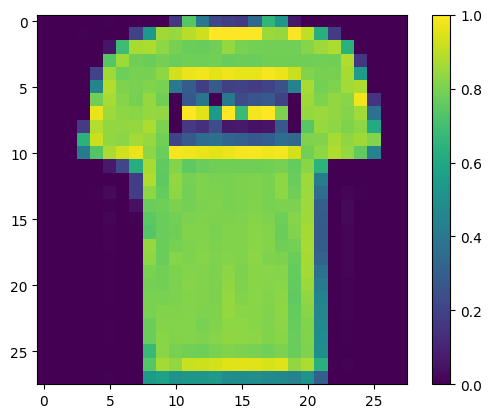

In [129]:
plt.figure()
plt.imshow(train_images[1])
plt.colorbar()
plt.grid(False)

In [121]:
train_images = train_images / 255.0
test_images = test_images / 255.0

### 3. Construir el modelo de Red Neuronal

Vamos a crear un modelo secuencial, que es una pila lineal de capas. Este modelo simple consta de:
*   **tf.keras.layers.Flatten**: Esta capa transforma el formato de las imágenes de un arreglo 2D (28x28 píxeles) a un arreglo 1D (28 * 28 = 784 píxeles). No hay parámetros que aprender en esta capa; solo reformatea los datos.
*   **tf.keras.layers.Dense (capa oculta)**: Esta es una capa completamente conectada (o densa). Tiene 128 neuronas. Cada neurona toma la entrada de todas las neuronas de la capa anterior, las multiplica por un peso, suma un sesgo y aplica una función de activación (ReLU en este caso). ReLU (`Rectified Linear Unit`) es una función de activación común que devuelve `output = max(0, input)`.
*   **tf.keras.layers.Dense (capa de salida)**: Esta es la capa final, también densa. Tiene 10 neuronas, una por cada clase de ropa. La función de activación `softmax` asegura que la salida de cada neurona sea una probabilidad (entre 0 y 1) y que la suma de todas las probabilidades sea 1. La neurona con la probabilidad más alta es la predicción de la clase.

In [122]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)), # Capa de entrada: aplana las imágenes 28x28 a un vector de 784 píxeles
    tf.keras.layers.Dense(128, activation='relu'),   # Capa oculta: 128 neuronas con función de activación ReLU
    tf.keras.layers.Dense(10, activation='softmax')  # Capa de salida: 10 neuronas (una por clase) con activación Softmax para probabilidades
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 4. Compilar el modelo

Antes de entrenar el modelo, se deben configurar algunos ajustes:
*   **Optimizer (`'adam'`)**: Es el algoritmo que ajusta los pesos del modelo para minimizar la función de pérdida. Adam es un optimizador muy eficiente.
*   **Loss (`'sparse_categorical_crossentropy'`)**: Mide qué tan preciso es el modelo durante el entrenamiento. Es una función de pérdida adecuada para problemas de clasificación multiclase cuando las etiquetas son enteros (0, 1, 2, ...).
*   **Metrics (`'accuracy'`)**: Se utiliza para monitorear los pasos de entrenamiento y prueba. En este caso, la precisión es la fracción de imágenes que se clasificaron correctamente.

In [123]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### 5. Entrenar el modelo

El entrenamiento implica 'alimentar' el modelo con los datos de entrenamiento (`train_images` y `train_labels`). El modelo aprende a asociar las imágenes con sus etiquetas. El `epochs=10` indica que el modelo pasará 10 veces por todo el conjunto de datos de entrenamiento.

In [124]:
history = model.fit(train_images, train_labels, epochs=10, validation_split=0.2, verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7671 - loss: 0.6679 - val_accuracy: 0.8559 - val_loss: 0.4107
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8568 - loss: 0.3946 - val_accuracy: 0.8633 - val_loss: 0.3814
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8721 - loss: 0.3523 - val_accuracy: 0.8742 - val_loss: 0.3498
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8822 - loss: 0.3164 - val_accuracy: 0.8723 - val_loss: 0.3708
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8911 - loss: 0.2953 - val_accuracy: 0.8800 - val_loss: 0.3383
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8942 - loss: 0.2847 - val_accuracy: 0.8869 - val_loss: 0.3273
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9021 - loss: 0.2686 - val_accuracy: 0.8781 - val_loss: 0.3328
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9013 - loss: 0.2614 - 

### 6. Evaluar la precisión del modelo

Una vez entrenado, evaluamos el modelo con el conjunto de datos de prueba (`test_images` y `test_labels`) para ver qué tan bien se generaliza a datos que no ha visto antes.

In [125]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nPrecisión en el conjunto de prueba: {test_acc:.4f}')

313/313 - 1s - 2ms/step - accuracy: 0.8793 - loss: 0.3465

Precisión en el conjunto de prueba: 0.8793


### 7. Hacer predicciones

Ahora podemos usar el modelo entrenado para predecir las etiquetas de nuevas imágenes.

In [126]:
predictions = model.predict(test_images)

# La predicción para la primera imagen de prueba
print(f'Predicciones de probabilidad para la primera imagen: {predictions[0]}')

# La clase predicha es aquella con la mayor probabilidad
predicted_class = np.argmax(predictions[0])
print(f'Clase predicha para la primera imagen: {class_names[predicted_class]}')

# La etiqueta real de la primera imagen
print(f'Etiqueta real de la primera imagen: {class_names[test_labels[0]]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predicciones de probabilidad para la primera imagen: [9.8131522e-08 8.4129162e-08 4.6105217e-08 3.1576806e-07 4.2061991e-08
 1.3916274e-03 5.3401440e-08 1.9169763e-02 3.8826875e-07 9.7943759e-01]
Clase predicha para la primera imagen: Ankle boot
Etiqueta real de la primera imagen: Ankle boot


### 8. Visualizar resultados del entrenamiento

Podemos graficar la pérdida y la precisión del modelo a lo largo de las épocas para entender su rendimiento.

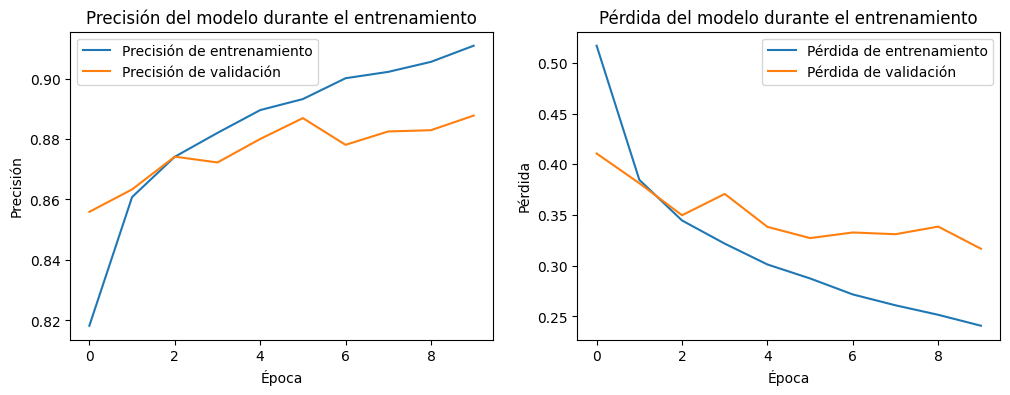

In [127]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión del modelo durante el entrenamiento')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Pérdida del modelo durante el entrenamiento')

plt.show()